In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures
from sklearn.metrics import mean_squared_error, r2_score

In [5]:
df = pd.read_csv('Salary_Data.csv')
print(df.head(10))       
print(df.shape)

   YearsExperience   Salary
0              1.1  39343.0
1              1.3  46205.0
2              1.5  37731.0
3              2.0  43525.0
4              2.2  39891.0
5              2.9  56642.0
6              3.0  60150.0
7              3.2  54445.0
8              3.2  64445.0
9              3.7  57189.0
(30, 2)


In [7]:
X = df[['YearsExperience']]  
y = df['Salary']               

In [8]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [10]:
lin_model = LinearRegression()
lin_model.fit(X_train, y_train)     
y_pred_lin = lin_model.predict(X_test)  

In [11]:
mse_lin = mean_squared_error(y_test, y_pred_lin)
r2_lin = r2_score(y_test, y_pred_lin)
print(f"Linear - MSE: {mse_lin:.2f}, R2: {r2_lin:.2f}")

Linear - MSE: 49830096.86, R2: 0.90


In [13]:
poly = PolynomialFeatures(degree=2, include_bias=False)
X_train_poly = poly.fit_transform(X_train)   
X_test_poly = poly.transform(X_test) 
X_train_poly
X_test_poly

array([[ 9.6 , 92.16],
       [ 4.9 , 24.01],
       [ 8.2 , 67.24],
       [ 5.3 , 28.09],
       [ 3.2 , 10.24],
       [ 3.7 , 13.69]])

In [14]:
poly_model = LinearRegression()
poly_model.fit(X_train_poly, y_train)
y_pred_poly = poly_model.predict(X_test_poly)

In [15]:
mse_poly = mean_squared_error(y_test, y_pred_poly)
r2_poly = r2_score(y_test, y_pred_poly)
print(f"Poly (deg=2) - MSE: {mse_poly:.2f}, R2: {r2_poly:.2f}")

Poly (deg=2) - MSE: 52527916.37, R2: 0.90


In [16]:
degrees = range(1, 11)
mse_list = []
r2_list = []

for d in degrees:
    poly = PolynomialFeatures(degree=d, include_bias=False)
    X_train_poly = poly.fit_transform(X_train)
    X_test_poly = poly.transform(X_test)
    
    model = LinearRegression()
    model.fit(X_train_poly, y_train)
    y_pred = model.predict(X_test_poly)
    
    mse_list.append(mean_squared_error(y_test, y_pred))
    r2_list.append(r2_score(y_test, y_pred))

In [17]:
mse_list

[49830096.85590839,
 52527916.36877493,
 48605815.3318871,
 49557837.2610732,
 46560480.97513509,
 44676156.57197935,
 54512859.12382228,
 53471815.000193864,
 71128663.17710036,
 49715871.04248298]

In [18]:
r2_list

[0.9024461774180497,
 0.8971645780890871,
 0.9048429887854867,
 0.9029791879054182,
 0.9088471990429207,
 0.9125361954549455,
 0.893278598217903,
 0.8953166804241266,
 0.8607493578000661,
 0.9026698005984221]

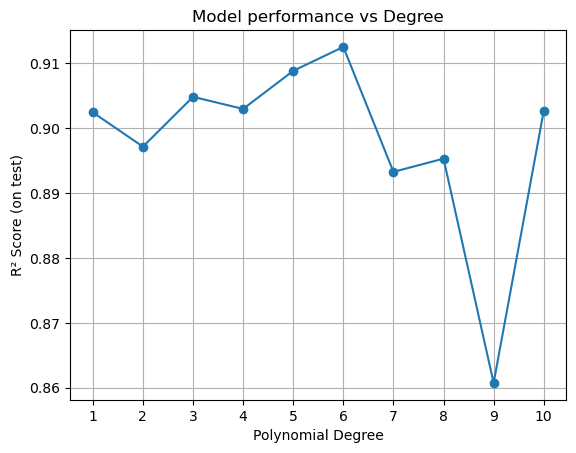

In [20]:
plt.plot(degrees, r2_list, marker='o')
plt.xlabel('Polynomial Degree')
plt.ylabel('R² Score (on test)')
plt.title('Model performance vs Degree')
plt.xticks(degrees)
plt.grid(True)
plt.show()